In [4]:
import os
from collections import defaultdict

import numpy as np
from astropy.io import fits

import numpy as np
import pandas as pd

from astropy.convolution import convolve
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, SourceCatalog
from photutils.psf import IntegratedGaussianPRF


# ==============================
# 設定：データが入っているディレクトリ
# ==============================
base_dir = "./FOCUSING_20250915"

# ==============================
# 1. ファイルを group_id ごとにまとめる
#    group_dict["00012"]["fits"] → [(idx, path), ...]
#    group_dict["00012"]["meta"] → "...._00012_meta.json"
# ==============================
group_dict = defaultdict(lambda: {"fits": [], "meta": None})

for fname in os.listdir(base_dir):

    # 必要なら prefix で絞る（不要ならこの if は消してOK）
    if not fname.startswith("focustest_gcode4_5000_20250915_"):
        continue

    fpath = os.path.join(base_dir, fname)
    base, ext = os.path.splitext(fname)
    parts = fname.split("_")

    # 例:
    # focustest_gcode4_5000_20250915_00012_4.fits
    # focustest_gcode4_5000_20250915_00012_meta.json
    # → parts[-2] が "00012"
    group_id = parts[-2]

    # FITS ファイル
    if ext == ".fits":
        # parts[-1] は "4.fits" なので、".fits" を外して index にする
        idx_str = os.path.splitext(parts[-1])[0]
        idx = int(idx_str)
        group_dict[group_id]["fits"].append((idx, fpath))

    # meta.json
    elif fname.endswith("_meta.json"):
        group_dict[group_id]["meta"] = fpath

# index 順にソートしておくと後で扱いやすい
for gid, entry in group_dict.items():
    entry["fits"].sort(key=lambda x: x[0])

# ==============================
# 2. 各 group_id ごとに FITS を読み込む
#    images_dict["00012"] → shape = (n_frames, ny, nx)
# ==============================
images_dict = {}   # 画像本体
meta_dict   = {}   # meta ファイルパス（必要なら中身を読む用）

for gid, entry in group_dict.items():
    image_list = []

    for idx, fpath in entry["fits"]:
        print(f"[{gid}] Loading idx={idx}: {fpath}")
        with fits.open(fpath) as hdul:
            # HSC の場合は拡張1が画像なことが多いので [1] を使用
            image_list.append(hdul[1].data)

    if image_list:
        images_dict[gid] = np.array(image_list)  # (n_frames, ny, nx)

    meta_dict[gid] = entry["meta"]

# ==============================
# 3. 使い方の例
# ==============================
# 例: group_id "00012" の画像スタックを取り出す
if "00012" in images_dict:
    imgs_00012 = images_dict["00012"]   # imgs_00012.shape → (n_frames, ny, nx)
    print("00012 stack shape:", imgs_00012.shape)
    print("00012 meta file:", meta_dict["00012"])
else:
    print("group_id '00012' は見つかりませんでした")


[00008] Loading idx=0: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_0.fits
[00008] Loading idx=1: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_1.fits
[00008] Loading idx=2: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_2.fits
[00008] Loading idx=3: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_3.fits
[00008] Loading idx=4: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_4.fits
[00008] Loading idx=5: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_5.fits
[00002] Loading idx=0: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00002_0.fits
[00002] Loading idx=1: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00002_1.fits
[00002] Loading idx=2: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00002_2.fits
[00002] Loading idx=3: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00002_3.fits
[00002] Loading idx=4: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00002_4.fits
[00002] Loading idx=5: ./FOCUSING_20250915/

In [5]:
print(images_dict.keys())

dict_keys(['00008', '00002', '00007', '00001', '00006', '00010', '00012', '00011', '00000', '00009', '00003', '00005', '00004'])


In [6]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

def show_focus_group(image_dict, group_id, vmin=75, vmax=150):
    """
    image_dict[group_id] 内の画像を、
    元コードと同じ 1x6 グリッドで表示する
    """

    if group_id not in image_dict:
        print(f"Group ID {group_id} was not found.")
        return

    image_list = image_dict[group_id]   # shape = (N, H, W)
    n_images = len(image_list)

    # --- Figure レイアウト（あなたの元コードをそのまま踏襲） ---
    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(1, n_images, hspace=0, wspace=0.1)
    plt.subplots_adjust(wspace=0, hspace=0)

    axs = [fig.add_subplot(gs[0, i]) for i in range(n_images)]

    # --- 画像ごとの描画 ---
    for i, ax in enumerate(axs):
        ax.set_title(f"CMOS {i}", ha='center', va='center')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(image_list[i], vmin=vmin, vmax=vmax, origin='lower')

    plt.show()


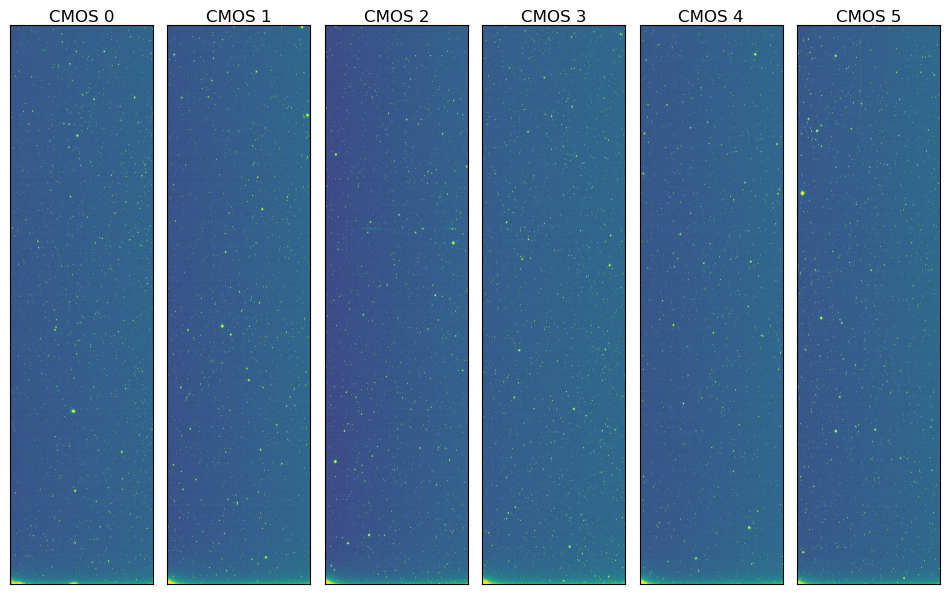

In [7]:
show_focus_group(images_dict, "00012")

In [19]:
from photutils.psf import CircularGaussianSigmaPRF
from astropy.convolution import convolve
from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, SourceCatalog
import numpy as np
import pandas as pd

def detection(data, nrows, ncols):
    """
    1枚の画像 data に対してソース検出を行い、
    segmentation map, SourceCatalog, pandas DataFrame を返す。
    """
    # -------------------------------
    # 背景推定
    bkg = Background2D(
        data,
        box_size=50,
        filter_size=3,
        bkg_estimator=MedianBackground()
    )
    data_sub = data - bkg.background

    # -------------------------------
    # PSF（簡易ガウシアン）でスムージング
    psf_model = CircularGaussianSigmaPRF(sigma=3)

    y, x = np.mgrid[-5:6, -5:6]
    psf = psf_model(x, y)
    psf /= np.sum(psf)

    # astropy.convolution.convolve
    smoothed = convolve(data_sub, psf)

    # -------------------------------
    # ピーク検出
    threshold = 10 * bkg.background_rms_median
    segm = detect_sources(smoothed, threshold, npixels=5)

    cat = SourceCatalog(data_sub, segm)
    print(f"検出した天体の数: {len(cat)}")

    a_sigma = cat.semimajor_sigma.value
    b_sigma = cat.semiminor_sigma.value
    sigma_mean = np.sqrt(a_sigma * b_sigma)
    fwhm_pix = sigma_mean * (2 * np.sqrt(2 * np.log(2)))

    pixel_scale = 0.23
    fwhm_arcsec = fwhm_pix * pixel_scale
    pa_rad = cat.orientation.to("rad").value
    pa_deg = np.degrees(pa_rad)

    det_smooth = pd.DataFrame({
        "ID": np.arange(1, len(cat) + 1),
        "xcentroid": cat.xcentroid,
        "ycentroid": cat.ycentroid,
        "segment_flux": cat.segment_flux,
        "a_sigma": a_sigma,
        "b_sigma": b_sigma,
        "fwhm_pix": fwhm_pix,
        "fwhm_arcsec": fwhm_arcsec,
        "b/a": b_sigma / a_sigma,
        "pa_deg": pa_deg,
    })

    # -------------------------------
    # グリッド ID を付ける
    ny, nx = data.shape
    dy, dx = ny / nrows, nx / ncols

    det_smooth["row_bin"] = (det_smooth["ycentroid"] // dy).astype(int)
    det_smooth["col_bin"] = (det_smooth["xcentroid"] // dx).astype(int)
    det_smooth["row_bin"] = det_smooth["row_bin"].clip(0, nrows - 1)
    det_smooth["col_bin"] = det_smooth["col_bin"].clip(0, ncols - 1)
    det_smooth["grid_id"] = det_smooth["row_bin"] * ncols + det_smooth["col_bin"]

    return segm, cat, det_smooth


In [20]:
from dask.distributed import get_client, as_completed
from tqdm.auto import tqdm
from collections import defaultdict

def run_detection_on_all_dask(image_dict, nrows, ncols):
    """
    dask.distributed.Client を使って detection を並列実行する版。
    事前にどこかで Client(...) を作っておくこと。

        client = Client(processes=True, n_workers=14, threads_per_worker=2)

    など。
    """
    client = get_client()  # 既存の Client を取得

    futures = []
    key_by_future = {}

    # --- 各フレームを distributed のワーカーに投げる ---
    for gid, imgs in image_dict.items():
        for idx, img in enumerate(imgs):
            # detection をそのまま submit（遅延タスクよりもグラフが小さい）
            fut = client.submit(detection, img, nrows, ncols)
            futures.append(fut)
            key_by_future[fut] = (gid, idx)

    print(f"Total tasks: {len(futures)}")

    detection_results = defaultdict(list)

    # --- 進捗バー付きで結果を回収 ---
    for fut in tqdm(as_completed(futures), total=len(futures)):
        segm, cat, det_smooth = fut.result()
        gid, idx = key_by_future[fut]

        detection_results[gid].append({
            "index": idx,
            "segm": segm,
            "catalog": cat,
            "table": det_smooth,
        })

    # --- index（フレーム番号）でソート ---
    for gid in detection_results:
        detection_results[gid].sort(key=lambda d: d["index"])

    return detection_results


In [21]:
import time
from dask.distributed import Client

# クラスタ（ローカルでもOK）を作る
client = Client(processes=True, n_workers=14, threads_per_worker=2)
print(client)

nrows, ncols = 4, 5

# --- 実行時間計測 ---
t0 = time.time()

det_results = run_detection_on_all_dask(images_dict, nrows, ncols)

t1 = time.time()

print(f"\n>>> run_detection_on_all_dask finished in {t1 - t0:.3f} seconds")
#Clientで実行しない場合は310s

/home/satoksk/miniconda3/envs/astro/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37015 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:43861' processes=14 threads=28, memory=188.64 GiB>


/home/satoksk/miniconda3/envs/astro/lib/python3.11/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 48.83 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


Total tasks: 78


  0%|          | 0/78 [00:00<?, ?it/s]


>>> run_detection_on_all_dask finished in 131.185 seconds


In [22]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

def show_focus_group_with_detections(image_dict, det_results, group_id,
                                     vmin=75, vmax=150, s=5):
    """
    すでに Dask などで計算済みの det_results を使って、
    image_dict[group_id] の各CMOS画像に検出位置を重ねて表示する。

    Parameters
    ----------
    image_dict : dict
        {group_id: [img0, img1, ...]} の形の辞書
    det_results : dict
        run_detection_on_all_local / run_detection_on_all_dask が返した結果。
        det_results[gid] は各フレームの dict のリストを想定。
    group_id : hashable
        表示したいキー（例: "00012"）
    vmin, vmax : float
        imshow の表示レンジ（全コマで揃える）
    s : float
        検出マーカーのサイズ（scatter の s）
    """

    # --- 存在チェック ---
    if group_id not in image_dict:
        print(f"Group ID {group_id} was not found in image_dict.")
        return

    if group_id not in det_results:
        print(f"Group ID {group_id} was not found in det_results.")
        return

    image_list = image_dict[group_id]
    n_images = len(image_list)

    # det_results[group_id] を index → record の dict にしておく
    frame_results = det_results[group_id]  # list of dicts
    idx_to_record = {rec["index"]: rec for rec in frame_results}

    # --- Figure レイアウト（元の show_focus_group と同じ 1 x N グリッド） ---
    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(1, n_images, hspace=0, wspace=0.1)
    plt.subplots_adjust(wspace=0, hspace=0)

    axs = [fig.add_subplot(gs[0, i]) for i in range(n_images)]

    # --- 各CMOSごとに描画 ---
    for i, (img, ax) in enumerate(zip(image_list, axs)):
        ax.set_title(f"CMOS {i}", ha='center', va='center', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

        # 画像本体
        ax.imshow(img, vmin=vmin, vmax=vmax, origin='lower', cmap='gray')

        # このフレームに対応する detection 結果があればマーカーを描画
        if i in idx_to_record:
            det_smooth = idx_to_record[i]["table"]  # pandas DataFrame
            if len(det_smooth) > 0:
                ax.scatter(
                    det_smooth["xcentroid"],
                    det_smooth["ycentroid"],
                    s=s,
                    edgecolors='red',
                    facecolors='none',  # 中抜き円にしたい場合
                    lw=0.5,
                )

    plt.show()


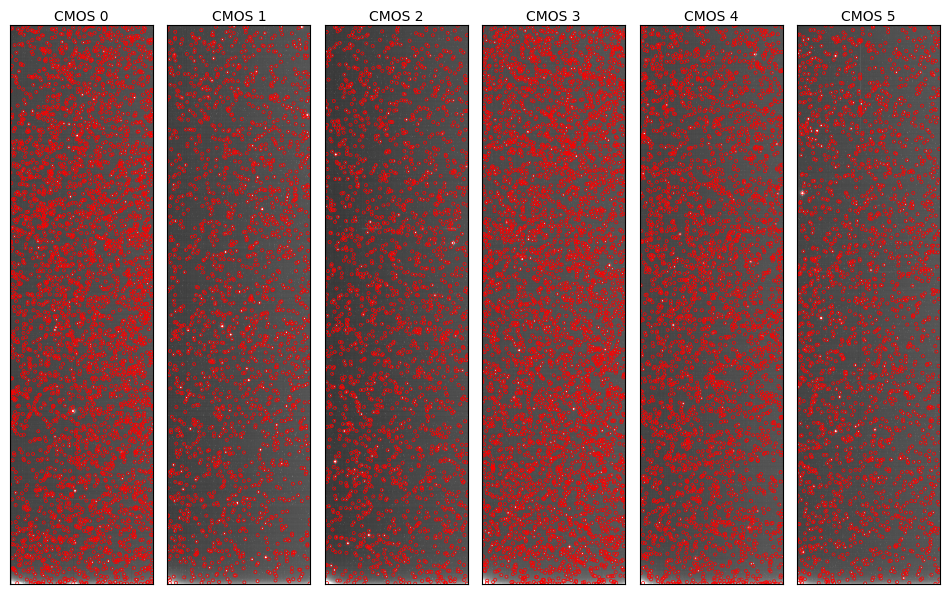

In [23]:
show_focus_group_with_detections(
    images_dict,
    det_results,
    "00012",   # ← dict の key（group_id）
    vmin=75,
    vmax=150,
    s=5,
)